In [9]:
#conda activate burnseverity
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import requests
import json

import rioxarray as rxr

import geopandas as gpd

import validation as val



The goal of this notebook is to compare per-pixel dNBR values between our tool and the official BAER assessments for the fire where we have those. The goal is to do the following:
1. Regrid all rasters to 30 m resolution (Landsat)
2. Crop all raster to the respective CalFire boundaries to define a common domain
3. Calculate the per pixel $R^2$ 

In [14]:
#load job list
fire_jobs = pd.read_csv("fire_processing_jobs.csv")
fire_jobs[fire_jobs['fire_name'] == 'GEOLOGY'].head()


,fire_event_name,job_id,fire_name,date_mode,post_fire_days,status,job_status
80,GEOLOGY_date2023-06-10_range5_modealarm,9e43a061-fc76-4e96-9e18-0bd595b31343,GEOLOGY,alarm,5,success,complete
81,GEOLOGY_date2023-06-10_range10_modealarm,b93dbc6b-0bbe-4dd8-b2ed-2e0a57252ffe,GEOLOGY,alarm,10,success,complete
82,GEOLOGY_date2023-06-10_range15_modealarm,5c89f437-dc1d-42a7-9a05-660d8eb8475d,GEOLOGY,alarm,15,success,complete
83,GEOLOGY_date2023-06-10_range21_modealarm,ba086e34-6a7f-4ccf-a585-3e7f72de2bad,GEOLOGY,alarm,21,success,complete
84,GEOLOGY_date2023-06-10_range30_modealarm,7c39efec-3665-4376-9a06-661b480785f3,GEOLOGY,alarm,30,success,complete


In [34]:


fire_jobs = pd.read_csv("fire_processing_jobs.csv")

fire_event_name = 'GEOLOGY_date2023-06-10_range30_modealarm'
row = fire_jobs[fire_jobs['fire_event_name'] == fire_event_name].iloc[0]
job_id = row['job_id']

request = requests.get(f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}")
response_data = request.json()
response_data


{'fire_event_name': 'GEOLOGY_date2023-06-10_range30_modealarm',
 'status': 'complete',
 'job_id': '7c39efec-3665-4376-9a06-661b480785f3',
 'coarse_severity_cog_urls': {'rbr': 'https://storage.googleapis.com/fire-recovery-store/assets/7c39efec-3665-4376-9a06-661b480785f3/fire_severity/rbr.tif',
  'dnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/7c39efec-3665-4376-9a06-661b480785f3/fire_severity/dnbr.tif',
  'rdnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/7c39efec-3665-4376-9a06-661b480785f3/fire_severity/rdnbr.tif'}}

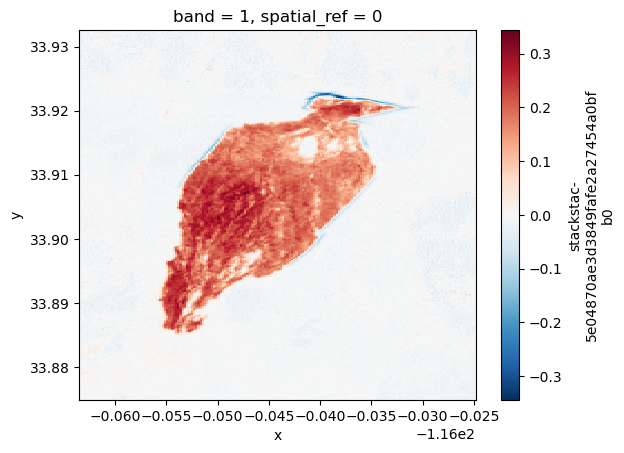

In [35]:
if response_data.get('status') != 'complete':
    print(f"  Job {fire_event_name} is {response_data.get('status')}")

urls = response_data.get('coarse_severity_cog_urls')
dnbr_url = urls.get('dnbr')
rbr_url = urls.get('rbr')

ref_raster = rxr.open_rasterio(dnbr_url)
ref_raster.plot()

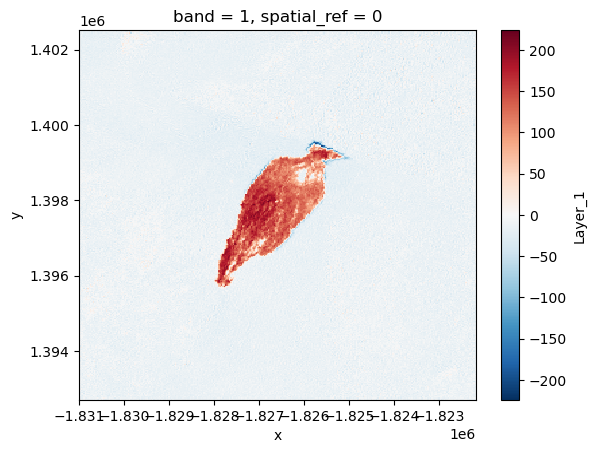

In [32]:
baer = rxr.open_rasterio("baer/organized/GEOLOGY_2023-06-10/ca3389711605420230610_20230603_20230619_dnbr.tif")
baer.plot()

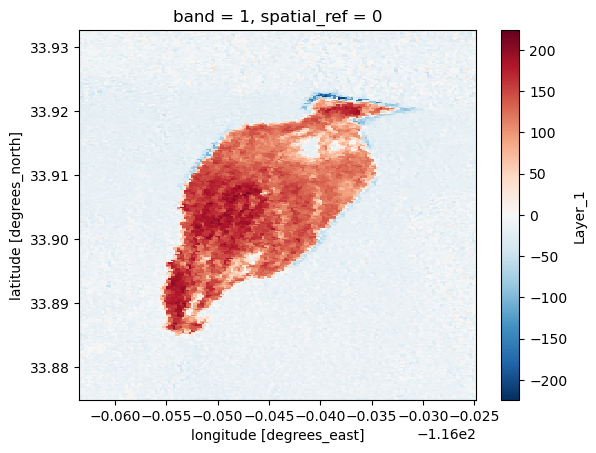

In [33]:
resampled = baer.rio.reproject_match(ref_raster)
resampled.plot()